In [1]:
!pip install pyspark


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### PySpark Framework
##### PySpark is the Python API for Apache Spark. It enables you to perform real-time, large-scale data processing in a distributed environment using Python.<br>

##### PySpark supports all of Spark’s features through the following APIs:
1. Spark SQL API - for Spark SQL and Dataframes
2. Pandas API - for Pandas
3. Structured Streaming API - for 
4. Machine Learning (MLlib) API
5. Pipelines API
6. Spark Core API

Spark SQL API <br>
Link: https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/index.html <br>
Import reference: <b>pyspark.sql.<Core_classes or Functions></b>

In [1]:
# Importing multiple classes from pyspark.sql api
from pyspark.sql import SparkSession

# Importing multiple functions from pyspark.sql api
from pyspark.sql.functions import count, desc, col, max, struct

import matplotlib.pyplot as plt

In [1]:
from pyspark import SparkConf
from pyspark.sql import SparkSession

# spark = SparkSession.builder.appName("spark_app") \
#     .config("spark.executor.instances", "10")\
#     .config("spark.executor.cores", "5")\
#     .config("spark.executor.memory", "8g")\
#     .config("spark.shuffle.service.enabled", "true").getOrCreate()
    
conf = SparkConf().setAppName("MyApp") \
                  .set("spark.executor.instances", "5") \
                  .set("spark.executor.memory", "8g") \
                  .set("spark.executor.cores", "5")

spark = SparkSession.builder.config(conf=conf).getOrCreate()
sc = spark.sparkContext
print(sc)

<SparkContext master=local[*] appName=MyApp>


In [2]:
sc.getConf().getAll() 

[('spark.app.id', 'local-1780242859496'),
 ('spark.rdd.compress', 'True'),
 ('spark.executor.instances', '5'),
 ('spark.hadoop.fs.s3a.vectored.read.min.seek.size', '128K'),
 ('spark.app.startTime', '1780242857511'),
 ('spark.sql.artifact.isolation.enabled', 'false'),
 ('spark.executor.extraJavaOptions',
  '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-modules=jdk.incubator.vector --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-open

In [3]:
spark = SparkSession.builder.appName("spark_app").getOrCreate()

### Importing the listening.csv

In [4]:
# Importing the listening.csv
listening_csv_path = "dataset\\listenings.csv"
listening_df = spark.read.format("csv")\
        .option("inferSchema", True)\
        .option("header", True)\
        .load(listening_csv_path)


##### Note: spark.read.format("csv") is used when building robust, dynamic ETL pipelines.

In [5]:
listening_df.show(5) #This is a PySpark DataFrame, not a Pandas DataFrame

+-----------+-------------+--------------------+---------+-----------------+
|    user_id|         date|               track|   artist|            album|
+-----------+-------------+--------------------+---------+-----------------+
|000Silenced|1299680100000|           Price Tag| Jessie J|      Who You Are|
|000Silenced|1299679920000|Price Tag (Acoust...| Jessie J|        Price Tag|
|000Silenced|1299679440000|Be Mine! (Ballad ...|    Robyn|         Be Mine!|
|000Silenced|1299679200000|            Acapella|    Kelis|         Acapella|
|000Silenced|1299675660000|   I'm Not Invisible|The Tease|I'm Not Invisible|
+-----------+-------------+--------------------+---------+-----------------+
only showing top 5 rows


#### Difference between a PySpark DataFrame and a Pandas DataFrame
1. Single Node computing (Pandas) vs Distributed computing (PySpark)
2. Eager Evaluation (Pandas) vs Lazy Evaluation (PySpark). Operations are executed immediately in Pandas, whereas PySpark does not execute operations immediately.
3. Not Scalable vs Scalability.


#### A. The Catalyst Optimizer (The Brain)
When you submit a PySpark command (like df.where()), it goes straight to the Catalyst Optimizer. Catalyst doesn't care if the code started as Python or SQL; it converts it into an abstract mathematical tree and optimizes it by:

Pushing down filters: Moving your .filter() conditions as close to the data source as possible so Spark reads less data from the disk.

Pruning columns: Ignoring columns you didn't select so they don't waste memory.

Reordering joins: Figuring out the most efficient way to match two datasets together.

#### B. The Tungsten Engine (The Muscle)
Once Catalyst creates the perfect physical execution plan, the Tungsten Engine takes over to make it run at hardware-level speed.

Whole-Stage Code Generation: Tungsten flattens your entire multi-step DataFrame operation into a single, highly optimized piece of Java bytecode.

Off-Heap Memory: It bypasses Python completely (and largely bypasses standard Java garbage collection) by managing raw memory bytes directly, avoiding memory overhead.

#### Dropping Columns

In [6]:
listening_df = listening_df.drop("date")

In [7]:
# Dropping the null rows
listening_df = listening_df.na.drop()

In [8]:
listening_df.show(5)

+-----------+--------------------+---------+-----------------+
|    user_id|               track|   artist|            album|
+-----------+--------------------+---------+-----------------+
|000Silenced|           Price Tag| Jessie J|      Who You Are|
|000Silenced|Price Tag (Acoust...| Jessie J|        Price Tag|
|000Silenced|Be Mine! (Ballad ...|    Robyn|         Be Mine!|
|000Silenced|            Acapella|    Kelis|         Acapella|
|000Silenced|   I'm Not Invisible|The Tease|I'm Not Invisible|
+-----------+--------------------+---------+-----------------+
only showing top 5 rows


#### Checking the data types being stored in a DataFrame

In [9]:
listening_df.printSchema()

root
 |-- user_id: string (nullable = true)
 |-- track: string (nullable = true)
 |-- artist: string (nullable = true)
 |-- album: string (nullable = true)



#### Checking the shape of our DataFrame

In [10]:
# We do not have a "shape" property in PySpark DataFrames
shape = (listening_df.count(), len(listening_df.columns))
print(shape)

(13758905, 4)


Select two columns - 'artist' and 'track'

In [11]:
query_0 = listening_df.select('artist', 'track')
query_0.show()

+---------------+--------------------+
|         artist|               track|
+---------------+--------------------+
|       Jessie J|           Price Tag|
|       Jessie J|Price Tag (Acoust...|
|          Robyn|Be Mine! (Ballad ...|
|          Kelis|            Acapella|
|      The Tease|   I'm Not Invisible|
|       MSTRKRFT|Bounce (Feat NORE...|
|        Rihanna|Don't Stop The Mu...|
|      Meshuggah|               ObZen|
|         Gojira|   Yama's Messengers|
|   Napalm Death|On the Brink of E...|
|   Napalm Death|On the Brink of E...|
|   Napalm Death|        In Deference|
|    Decapitated|      Post(?)organic|
|   Dom & Roland|        Mind Feeders|
|Cannibal Corpse|Necrosadistic War...|
|   Dom & Roland|     Dance All Night|
|   Dom & Roland|          Late Night|
|   Dom & Roland|          Freak Seen|
|   Dom & Roland|Paradrenasite (Hi...|
|   Dom & Roland|               Rhino|
+---------------+--------------------+
only showing top 20 rows


Find the users who listened to artist = 'Rihanna'

In [12]:
query_1 = listening_df.select('*').filter(listening_df.artist == "Rihanna") #Uses DataFrame attribute access
query_1_a = listening_df.select('*').where(col("artist") == "Rihanna") #Uses the col() function from pyspark.sql.functions
query_1.show(5)
query_1_a.show(5)

+-----------+--------------------+-------+--------------------+
|    user_id|               track| artist|               album|
+-----------+--------------------+-------+--------------------+
|000Silenced|Don't Stop The Mu...|Rihanna|Addicted 2 Bassli...|
|000Silenced|           Disturbia|Rihanna|Good Girl Gone Ba...|
|00williamsl|   Hatin On The Club|Rihanna|              Random|
|00williamsl|   Hatin On The Club|Rihanna|              Random|
|00williamsl|         Complicated|Rihanna|                Loud|
+-----------+--------------------+-------+--------------------+
only showing top 5 rows
+-----------+--------------------+-------+--------------------+
|    user_id|               track| artist|               album|
+-----------+--------------------+-------+--------------------+
|000Silenced|Don't Stop The Mu...|Rihanna|Addicted 2 Bassli...|
|000Silenced|           Disturbia|Rihanna|Good Girl Gone Ba...|
|00williamsl|   Hatin On The Club|Rihanna|              Random|
|00williamsl|   

<h3> Points to keep in mind </h3>
<b>filter()</b> and <b>where()</b> are synonyms in the DataFrame API.<br> 
Both the following expressions are valid and you can use them interchangeably inside the filter() and where(): 
<code>
listening_df.artist == "Rihanna" <br>
col("artist") == "Rihanna"
</code>

1. <code>listening_df.artist == "Rihanna"</code> is useful when the column name is a valid Python identifier. <br>

2. <code>col("artist") == "Rihanna"</code> is useful when column names contain spaces or special characters or they are not valid Python identifiers.

Find the top 10 users who are fan of Rihanna

In [13]:
query_2 = listening_df.select('user_id').where(col("artist") == "Rihanna").\
    groupBy("user_id").agg(count("user_id").alias("count")).orderBy(desc("count")).limit(10)
query_2.show()

+---------------+-----+
|        user_id|count|
+---------------+-----+
|        thiessu|  179|
|    eyessetkyle|  166|
|           adxx|  164|
|missnumberthree|  156|
|helloiamnatalie|  128|
|          nmjnb|  124|
|        AndyyyA|  123|
|     BIGBANG186|  121|
|     mixedvibes|  120|
|       AndyKitt|  115|
+---------------+-----+



### Importing genre.csv

In [15]:
genre_csv_path = "C:\\Personal_Projects\\Data Analysis using Pyspark\\dataset\\genre.csv"
genre_df = spark.read.format("csv")\
        .option("inferSchema", True)\
        .option("header", True)\
        .load(genre_csv_path)
        
genre_df.show()

+--------------------+-----+
|              artist|genre|
+--------------------+-----+
|                Muse| rock|
|             Nirvana| rock|
|            Bon Jovi| rock|
|          The Police| rock|
|                Kiss| rock|
|       Guns N' Roses| rock|
|         Rusted Root| rock|
|Katrina and the W...|  pop|
|         The Beatles| rock|
|        Hall & Oates|  pop|
|        Otis Redding| soul|
|         Marvin Gaye| soul|
|     The Cranberries| rock|
|            Survivor| rock|
|       Fleetwood Mac|blues|
|           Radiohead| rock|
|                Toto| rock|
|                  U2| rock|
|Creedence Clearwa...| rock|
|                 REM| rock|
+--------------------+-----+
only showing top 20 rows


Joining two dataframes: Listening_df INNER JOIN Genre_df

In [16]:
data = listening_df.join(genre_df,  how="inner", on="artist")
data.show()

+------------+-----------+--------------------+--------------------+--------------------+
|      artist|    user_id|               track|               album|               genre|
+------------+-----------+--------------------+--------------------+--------------------+
|    Jessie J|000Silenced|           Price Tag|         Who You Are| Ariana Grande & ...|
|    Jessie J|000Silenced|           Price Tag|         Who You Are| Jhene Aiko & Rixton|
|    Jessie J|000Silenced|           Price Tag|         Who You Are| Nicki Minaj & Ar...|
|    Jessie J|000Silenced|           Price Tag|         Who You Are|                 pop|
|    Jessie J|000Silenced|Price Tag (Acoust...|           Price Tag| Ariana Grande & ...|
|    Jessie J|000Silenced|Price Tag (Acoust...|           Price Tag| Jhene Aiko & Rixton|
|    Jessie J|000Silenced|Price Tag (Acoust...|           Price Tag| Nicki Minaj & Ar...|
|    Jessie J|000Silenced|Price Tag (Acoust...|           Price Tag|                 pop|
|       Ro

Find top 10 users who are fan of pop music

In [19]:
query_3 = data.select('user_id').where(col("genre") == "pop").\
    groupBy("user_id").agg(count("*").alias("count")).orderBy(desc("count")).limit(10)
query_3.show()

+---------------+-----+
|        user_id|count|
+---------------+-----+
|        01Green|  496|
|      momousagi|  400|
|          mrpsb|  400|
|   BlueKnockOut|  378|
|    musicboy80s|  376|
|  incultojurgis|  374|
| ElektricOrchid|  370|
|foreign_fanatic|  350|
|   Kevin_Soutar|  346|
|  landrover2171|  301|
+---------------+-----+



Find out each user favorite genre

In [30]:
query_4_a = data.select('user_id', 'genre').groupBy("user_id", "genre").agg(count("*").alias("count")).orderBy('user_id')
query_4_a.show()

+-------+--------------------+-----+
|user_id|               genre|count|
+-------+--------------------+-----+
| --Seph|           anti-folk|    3|
| --Seph| Capella Istropol...|    2|
| --Seph|     Hilko Schomerus|    1|
| --Seph| Arnór Dan & Doug...|    1|
| --Seph|                fado|    1|
| --Seph|        experimental|    3|
| --Seph|             Rihanna|    1|
| --Seph|              reggae|    3|
| --Seph|             ambient|    6|
| --Seph|    The Lady of Rage|    4|
| --Seph|             hip hop|    7|
| --Seph|      children music|    1|
| --Seph|            King Mez|    4|
| --Seph|                funk|    1|
| --Seph| Ne-Yo & Nicky Ro...|    1|
| --Seph| brazilian pop music|    1|
| --Seph|                rock|   27|
| --Seph|               Bjorn|    8|
| --Seph|          ninja tune|    1|
| --Seph|             baroque|    1|
+-------+--------------------+-----+
only showing top 20 rows


Using struct() function: allowing us to combine two or more columns

In [37]:
query_4_b = query_4_a.groupBy('user_id').agg(max(struct("count", "genre")).alias("max_count_genre"))\
    .select("user_id", col("max_count_genre.genre").alias("genre"), col("max_count_genre.count").alias("count"))
query_4_b.show()

+---------------+-----------+-----+
|        user_id|      genre|count|
+---------------+-----------+-----+
|      --Shinn--|       rock|  112|
|        -Gemma-|british pop|   38|
|         -wasp-|       rock|   40|
|   -x-kelsey-x-|        pop|   61|
|      00fieldsy|       rock|   81|
|     01higginsr|    hip hop|  106|
|        0Chris0|    hip hop|   38|
|    12thmarquis|       rock|   52|
|           1936|        pop|   54|
|        1Marley|        r&b|  136|
|       1chris90|        pop|   48|
|     200percent|       folk|   43|
|        20113hz|        pop|   90|
|20thCenturyGirl|       rock|   75|
|        247flix|   synthpop|   78|
|         2AmcD7|       rock|   42|
|           2key|    hip hop|   45|
|         2moo2u| indie rock|   24|
|        3stripe| electronic|   46|
|            462|   shoegaze|   98|
+---------------+-----------+-----+
only showing top 20 rows


### Visualizing Data

Find out how many 'pop', 'rock', 'metal', and 'hip hop' singers we have and then visualize using bar chart and pie chart

In [61]:
query_5 = genre_df.select('genre', 'artist').where(col('genre').isin(['pop', 'rock', 'metal', 'hip hop']))\
    .groupBy('genre').agg(count(col('*')).alias('count'))
query_5.show()

+-------+-----+
|  genre|count|
+-------+-----+
|    pop| 6960|
|hip hop| 4288|
|  metal| 1854|
|   rock| 9066|
+-------+-----+



The 'artist' column gets implicitly dropped during the .groupBy().agg() operation.

For matplotlib, we need labels and values

In [62]:
# We will obtain labels and values using the collect() method, which returns a list of Row objects
query_5_list = query_5.collect()
labels = [row['genre'] for row in query_5_list]
values = [row['count'] for row in query_5_list]

In [63]:
print(labels)
print(values)

['pop', 'hip hop', 'metal', 'rock']
[6960, 4288, 1854, 9066]


<BarContainer object of 4 artists>

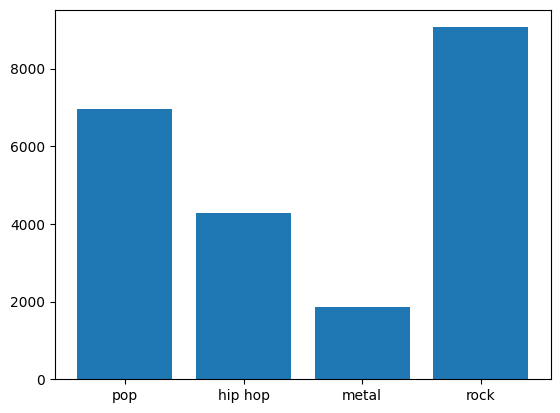

In [65]:
plt.bar(labels, values)

(np.float64(-1.0999998358716843),
 np.float64(1.099999992184366),
 np.float64(-1.0999912049166547),
 np.float64(1.0999991766644175))

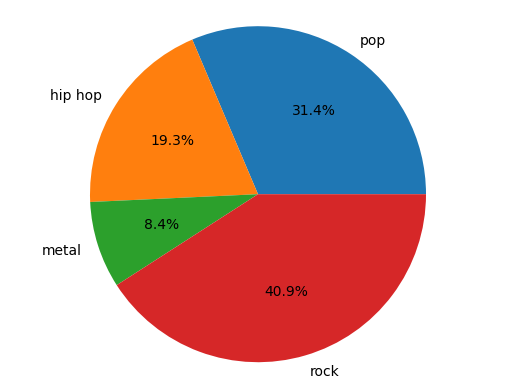

In [68]:
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular.